STL分解による予備分析を行う。

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.seasonal import STL
import seaborn as sns
import numpy as np

In [2]:
df = pd.read_csv('../data/Transport_amount_data.csv')
df['label'] = pd.to_datetime(df['label'])
df

,label,year,month,Transport_tonnage,number_parcels,Number_companies_1,Number_companies_2
0,2002-04-01,2002,4,5933686,218721,26,20
1,2002-05-01,2002,5,5474539,208283,26,20
2,2002-06-01,2002,6,5430018,218633,26,20
3,2002-07-01,2002,7,6345951,271764,26,20
4,2002-08-01,2002,8,5354671,217650,26,20
...,...,...,...,...,...,...,...
239,2022-03-01,2022,3,6118588,426615,24,14
240,2022-04-01,2022,4,5727532,387559,24,14
241,2022-05-01,2022,5,5102766,380692,24,14
242,2022-06-01,2022,6,5723215,411429,24,14


In [3]:
df = df.set_index('label')

In [4]:
# データの頻度を「月次(Month Start)」に設定（エラー回避のため推奨）
df.index.freq = 'MS' 

# 原系列は振幅が拡大している（乗法モデル的）ため、対数変換して加法モデル（STL）に適応させる
# ※状態空間モデルでも対数を用いたのと同じ理由です
df['log_parcels'] = np.log(df['number_parcels'])

stl = STL(df['log_parcels'], period=12, robust=True)
res = stl.fit()

stl_resid = res.resid
stl_resid

label
2002-04-01    0.000348
2002-05-01   -0.000009
2002-06-01    0.008767
2002-07-01    0.005000
2002-08-01    0.006107
                ...   
2022-03-01   -0.003791
2022-04-01   -0.006836
2022-05-01   -0.000293
2022-06-01   -0.006404
2022-07-01    0.007786
Freq: MS, Name: resid, Length: 244, dtype: float64

In [5]:
df_stl = pd.DataFrame({
    'original': df['log_parcels'].values,        # 元データ
    'trend': res.trend.values,                   # トレンド成分
    'seasonal': res.seasonal.values,             # 季節成分
    'residual': res.resid.values,                # 残差成分
    'fitted': (res.trend + res.seasonal).values 
}, index=df.index)  

df_stl

,original,trend,seasonal,residual,fitted
label,,,,,
2002-04-01,12.295552,12.327697,-0.032492,0.000348,12.295205
2002-05-01,12.246653,12.325593,-0.078930,-0.000009,12.246662
2002-06-01,12.295150,12.323552,-0.037169,0.008767,12.286383
2002-07-01,12.512689,12.321587,0.186103,0.005000,12.507689
2002-08-01,12.290644,12.319704,-0.035168,0.006107,12.284536
...,...,...,...,...,...
2022-03-01,12.963637,12.909578,0.057850,-0.003791,12.967429
2022-04-01,12.867623,12.910820,-0.036360,-0.006836,12.874460
2022-05-01,12.849746,12.912038,-0.061999,-0.000293,12.850039


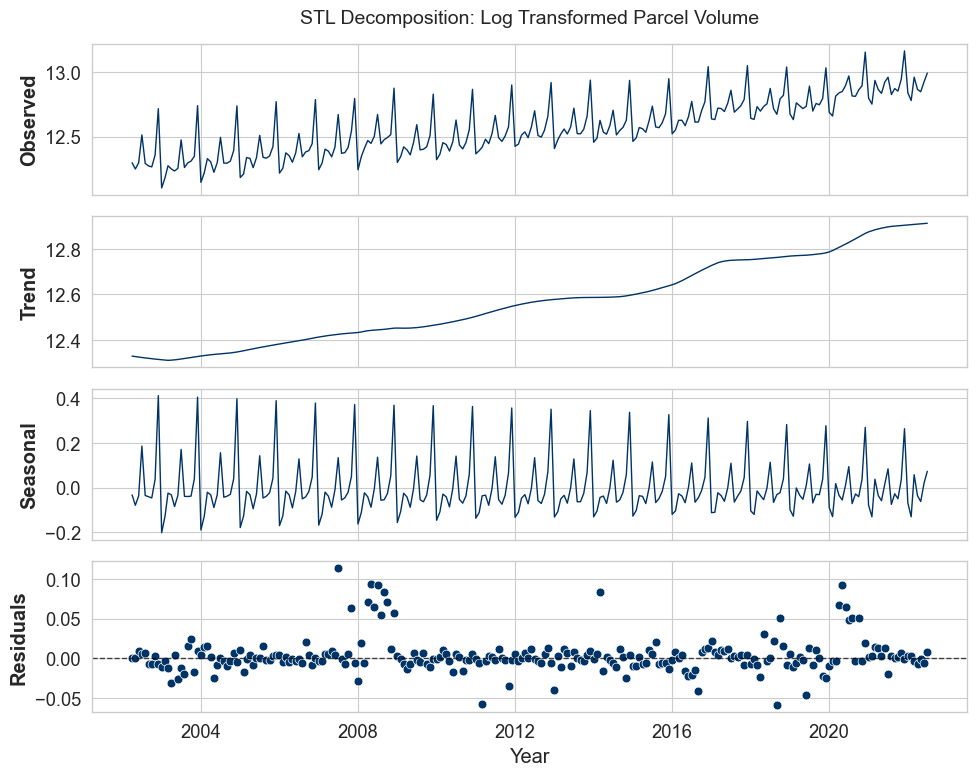

In [6]:
sns.set_context("paper", font_scale=1.5) 
sns.set_style("whitegrid") # 白背景＋グリッド

# 配色（落ち着いた紺色などを使用）
main_color = "#003366"  # 濃い青（論文で印刷してもきれいに出ます）
resid_color = "#CB3E0B" # 残差の強調用（必要なら変更可）

# -------------------------------------------------------
# 2. 描画キャンバスの作成（4段組み）
# -------------------------------------------------------
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)

# データ（resオブジェクト）から各成分を取得して描画
# ※ res は前のステップの stl.fit() の結果です

# --- (1) 原系列 (Observed) ---
sns.lineplot(data=res.observed, ax=axes[0], color=main_color, linewidth=1)
axes[0].set_ylabel('Observed', fontweight='bold')
axes[0].set_title('STL Decomposition: Log Transformed Parcel Volume', fontsize=14, pad=15)

# --- (2) トレンド (Trend) ---
sns.lineplot(data=res.trend, ax=axes[1], color=main_color, linewidth=1)
axes[1].set_ylabel('Trend', fontweight='bold')

# --- (3) 季節性 (Seasonal) ---
sns.lineplot(data=res.seasonal, ax=axes[2], color=main_color, linewidth=1)
axes[2].set_ylabel('Seasonal', fontweight='bold')

# --- (4) 残差 (Residuals) ---
# 残差は「点（scatter）」で描画するのが一般的です
sns.scatterplot(data=res.resid, ax=axes[3], color=main_color, s=40, edgecolor="white", linewidth=0.5)
# 0のラインを引く（基準線）
axes[3].axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.7)
axes[3].set_ylabel('Residuals', fontweight='bold')
axes[3].set_xlabel('Year') # 最後の段だけX軸ラベルを入れる

# -------------------------------------------------------
# 3. 仕上げ
# -------------------------------------------------------
# 軸ラベルの調整（不要な日付ラベルの間引きなど）
plt.tight_layout()

# 保存（高解像度で行う）
# plt.savefig("stl_decomposition_professional.png", dpi=300, bbox_inches='tight')

plt.show()

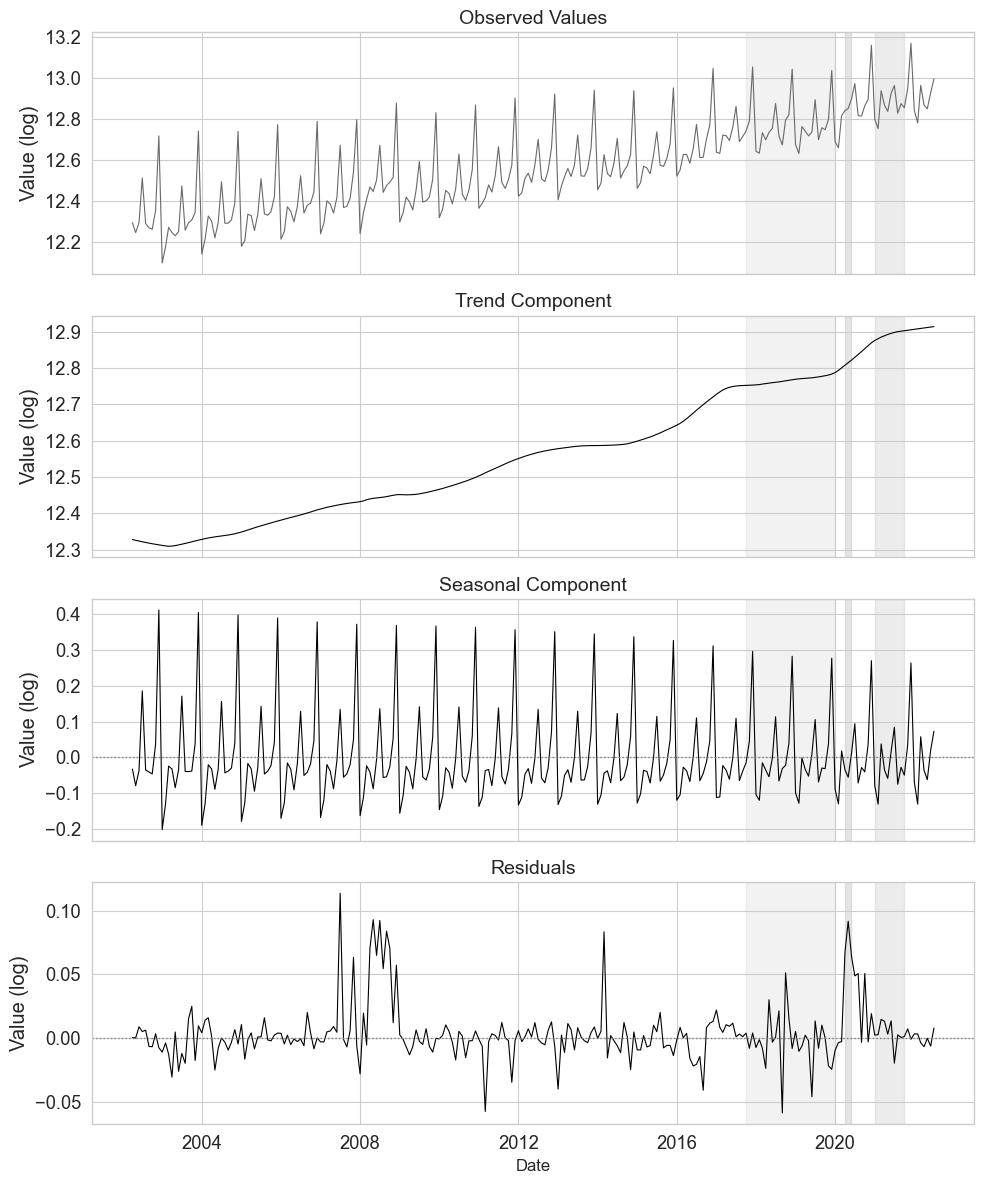

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# --- グラフの準備 ---
# STLは4成分なので4段にします (SSMは5段でした)
fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(10, 12), sharex=True)
sns.set_theme(style="whitegrid")

# データ（resオブジェクト）から各成分を取得して描画
# ※ res は stl.fit() の結果オブジェクトを想定しています

# --- 1. 観測値 (Observed) ---
# SSMに合わせて色を 'dimgray', 線幅を 0.8 に設定
axes[0].plot(res.observed.index, res.observed, color='dimgray', label='Observed', linewidth=0.8)
axes[0].set_title('Observed Values', fontsize=14)
# STLでは「Fitted」は明示的には出しませんが、必要なら Trend + Seasonal をプロット可能です
# axes[0].legend(loc='upper left') 

# --- 2. トレンド成分 (Trend) ---
axes[1].plot(res.trend.index, res.trend, color='black', label='Trend', lw=0.8)
axes[1].set_title('Trend Component', fontsize=14)
# トレンドは値のレベルによるため、ゼロ基準線は入れないことが一般的ですが、必要なら追加してください

# --- 3. 季節成分 (Seasonal) ---
axes[2].plot(res.seasonal.index, res.seasonal, color='black', label='Seasonal', lw=0.8)
axes[2].set_title('Seasonal Component', fontsize=14)
axes[2].axhline(y=0, color='grey', linestyle=':', linewidth=1) # ゼロ基準線

# --- 4. 残差 (Residuals) ---
# SSMのスタイルに合わせて、散布図(Scatter)ではなく折れ線(Plot)に変更します
axes[3].plot(res.resid.index, res.resid, color='black', linewidth=0.8, label='Residuals')
axes[3].set_title('Residuals', fontsize=14)
axes[3].axhline(y=0, color='grey', linestyle=':', linewidth=1) # ゼロ基準線

# --- 全グラフ共通の設定 (SSMのコードを移植) ---
for ax in axes:
    # イベント期間の背景色を追加
    ax.axvspan("2017-10-01", "2019-12-31", color='gray', alpha=0.1, zorder=-1)
    ax.axvspan("2020-04-01", "2020-05-31", color='gray', alpha=0.2, zorder=-1)
    ax.axvspan("2021-01-01", "2021-09-30", color='gray', alpha=0.15, zorder=-1)
    
    # Y軸ラベルの統一
    ax.set_ylabel('Value (log)')

# 最後のグラフにのみX軸のラベルを表示
axes[3].set_xlabel('Date', fontsize=12)

# レイアウトの自動調整
plt.tight_layout()

# 保存する場合
# plt.savefig("stl_decomposition_ssm_style.png", dpi=300, bbox_inches='tight')

# 表示
plt.show()

In [ ]:
# 2. ダミー変数の作成（論文の定義に基づく）
# -------------------------------------------------------
# 日付インデックスを使ってブールマスクを作成し、0/1に変換(astype(int))します

# (1) hike_dummy: 2017年10月 - 2019年12月
df['hike_dummy'] = 0
df.loc['2017-10-01':'2019-12-01', 'hike_dummy'] = 1

# (2) covid_main: 2020年03月 - 最後まで
df['covid_main'] = 0
df.loc['2020-03-01':, 'covid_main'] = 1

# (3) covid_wave1: 2020年04月 - 2020年05月
df['covid_wave1'] = 0
df.loc['2020-04-01':'2020-05-01', 'covid_wave1'] = 1

# (4) covid_2021: 2021年01月 - 2021年09月
df['covid_2021'] = 0
df.loc['2021-01-01':'2021-09-01', 'covid_2021'] = 1

# 確認
print("作成されたダミー変数の確認:")
print(df[['hike_dummy', 'covid_main', 'covid_wave1', 'covid_2021']].tail())

# -------------------------------------------------------
# 3. STL分解と残差の抽出
# -------------------------------------------------------
stl = STL(df['log_parcels'], period=12, robust=True)
res = stl.fit()
stl_resid = res.resid  # これが目的変数になります

# -------------------------------------------------------
# 4. OLS（重回帰分析）の実行
# -------------------------------------------------------
# 目的変数
Y = stl_resid

# 説明変数（定数項を追加）
features = ['hike_dummy', 'covid_main', 'covid_wave1', 'covid_2021']
X = df[features]
X = sm.add_constant(X)

# モデル作成と学習
model = sm.OLS(Y, X).fit()

# 結果の表示（詳細）
print("\n=== OLS Regression Results ===")
print(model.summary())

# -------------------------------------------------------
# 5. 論文用の表として整形
# -------------------------------------------------------
# 結果から必要な情報（係数、標準誤差、t値、p値）を抽出してDataFrameにする
results_table = pd.DataFrame({
    'Coefficient': model.params,
    'Std. Error': model.bse,
    't-value': model.tvalues,
    'p-value': model.pvalues,
    'Significant': model.pvalues < 0.05  # 5%有意かどうかのフラグ
})

# 小数点の桁数を丸める（論文掲載用）
results_table = results_table.round(4)

print("\n=== 論文掲載用テーブル（整形後） ===")
results_table

作成されたダミー変数の確認:
            hike_dummy  covid_main  covid_wave1  covid_2021
label                                                      
2022-03-01           0           1            0           0
2022-04-01           0           1            0           0
2022-05-01           0           1            0           0
2022-06-01           0           1            0           0
2022-07-01           0           1            0           0

=== OLS Regression Results ===
                            OLS Regression Results                            
Dep. Variable:                  resid   R-squared:                       0.111
Model:                            OLS   Adj. R-squared:                  0.097
Method:                 Least Squares   F-statistic:                     7.490
Date:                Thu, 25 Dec 2025   Prob (F-statistic):           1.06e-05
Time:                        13:36:48   Log-Likelihood:                 590.02
No. Observations:                 244   AIC:               

,Coefficient,Std. Error,t-value,p-value,Significant
const,0.0029,0.0016,1.8496,0.0656,False
hike_dummy,-0.0060,0.0045,-1.3329,0.1838,False
covid_main,0.0097,0.0054,1.8009,0.0730,False
covid_wave1,0.0667,0.0162,4.1112,0.0001,True
covid_2021,-0.0091,0.0089,-1.0206,0.3085,False


## ***SSMとSTLの比較***

In [9]:
df_ssm = pd.read_csv('../output/result_ssm.csv', index_col=0, parse_dates=True)
df_ssm

,trend,seasonal,hike_effect,covid_main_effect,covid_wave1_effect,covid_2021_effect,fitted,residual
label,,,,,,,,
2002-04-01,12.327668,-0.035178,-0.0,0.000000,0.0,0.0,12.292490,0.003063
2002-05-01,12.328829,-0.081681,-0.0,0.000000,0.0,0.0,12.247147,-0.000494
2002-06-01,12.330160,-0.037976,-0.0,0.000000,0.0,0.0,12.292184,0.002966
2002-07-01,12.330468,0.170054,-0.0,0.000000,0.0,0.0,12.500523,0.012166
2002-08-01,12.326577,-0.046942,-0.0,0.000000,0.0,0.0,12.279636,0.011008
...,...,...,...,...,...,...,...,...
2022-03-01,12.874458,0.019551,-0.0,0.048591,0.0,0.0,12.942600,0.021037
2022-04-01,12.871618,-0.052962,-0.0,0.048591,0.0,0.0,12.867247,0.000376
2022-05-01,12.868649,-0.063961,-0.0,0.048591,0.0,0.0,12.853279,-0.003533


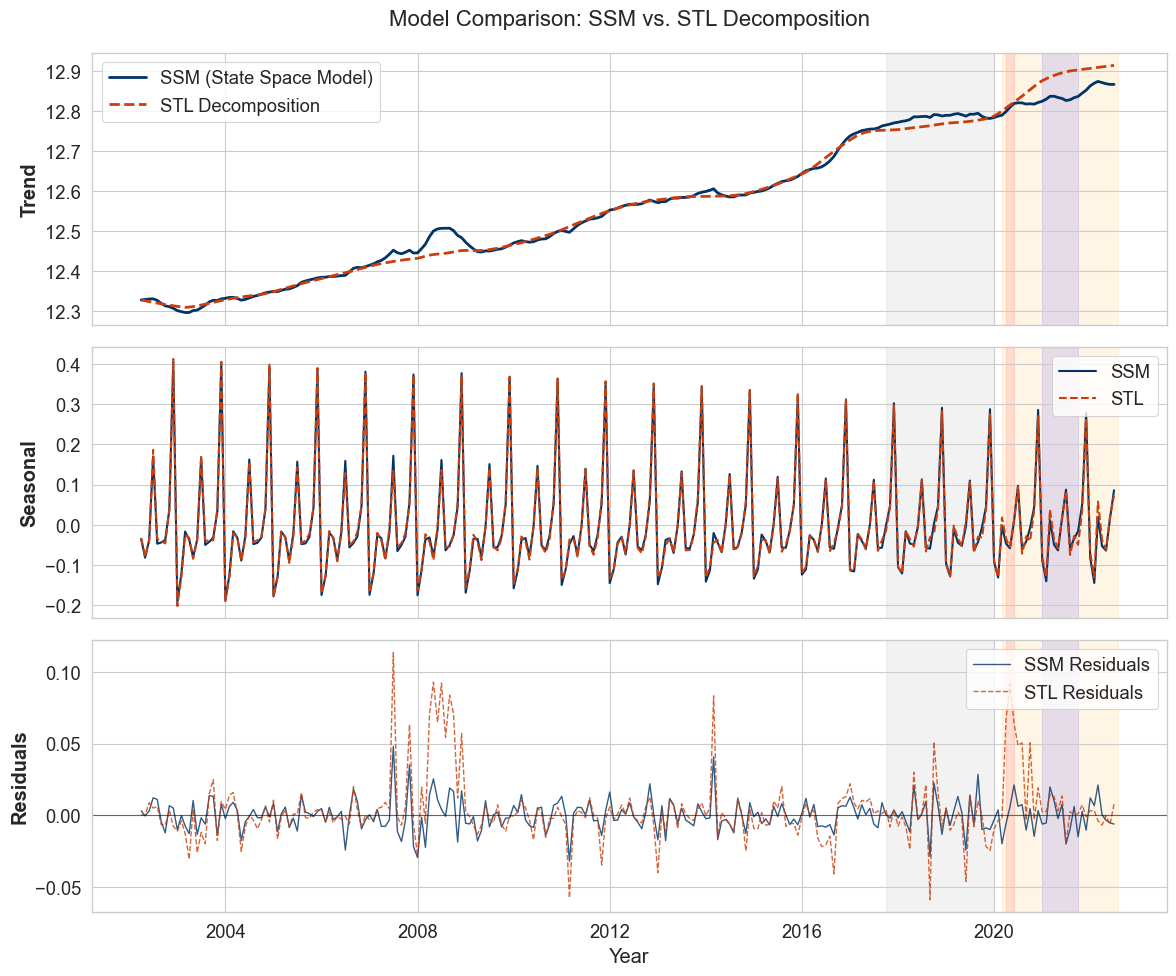

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. スタイル設定
sns.set_context("paper", font_scale=1.5)
sns.set_style("whitegrid")

# 配色設定
color_ssm = "#003366"  # 濃い青 (SSM用)
color_stl = "#CB3E0B"  # 濃いオレンジ/赤 (STL用)

# -------------------------------------------------------
# 2. 描画キャンバスの作成
# -------------------------------------------------------
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# --- (1) トレンド (Trend) ---
sns.lineplot(data=df_ssm, x=df_ssm.index, y='trend', ax=axes[0], 
             color=color_ssm, linewidth=2, label='SSM (State Space Model)')
sns.lineplot(data=df_stl, x=df_stl.index, y='trend', ax=axes[0], 
             color=color_stl, linewidth=2, linestyle='--', label='STL Decomposition')

axes[0].set_ylabel('Trend', fontweight='bold')
axes[0].set_title('Model Comparison: SSM vs. STL Decomposition', fontsize=16, pad=20)
axes[0].legend(loc='upper left', frameon=True)

# --- (2) 季節性 (Seasonal) ---
sns.lineplot(data=df_ssm, x=df_ssm.index, y='seasonal', ax=axes[1], 
             color=color_ssm, linewidth=1.5, label='SSM')
sns.lineplot(data=df_stl, x=df_stl.index, y='seasonal', ax=axes[1], 
             color=color_stl, linewidth=1.5, linestyle='--', label='STL')

axes[1].set_ylabel('Seasonal', fontweight='bold')
axes[1].legend(loc='upper right', frameon=True)

# --- (3) 残差 (Residuals) - ラインプロットへ変更 ---
# 線が重なって見づらくなるのを防ぐため、少し線を細くし(linewidth)、透明度(alpha)を調整しています
sns.lineplot(data=df_ssm, x=df_ssm.index, y='residual', ax=axes[2], 
             color=color_ssm, linewidth=1, alpha=0.8, label='SSM Residuals')
sns.lineplot(data=df_stl, x=df_stl.index, y='residual', ax=axes[2], 
             color=color_stl, linewidth=1, linestyle='--', alpha=0.8, label='STL Residuals')

# 基準線 (0ライン)
axes[2].axhline(0, color='black', linestyle='-', linewidth=0.8, alpha=0.5)
axes[2].set_ylabel('Residuals', fontweight='bold')
axes[2].set_xlabel('Year')
axes[2].legend(loc='upper right', frameon=True)

# --- 外生変数の期間定義 ---
events = [
    # (開始日, 終了日, イベント名, 色)
    ('2017-10-01', '2019-12-31', 'Price Hike', 'gray'),
    ('2020-03-01', '2022-07-31', 'COVID Main', 'orange'), 
    ('2020-04-01', '2020-05-31', 'Wave 1', 'red'),
    ('2021-01-01', '2021-09-30', '2021 Wave', 'blue')
]

# --- 描画処理 ---
for ax in axes:
    # 既存のグラフの上に、半透明の帯を引く
    for start, end, label, color in events:
        ax.axvspan(start, end, color=color, alpha=0.1, zorder=-1)

# -------------------------------------------------------
# 3. 仕上げ
# -------------------------------------------------------
plt.tight_layout()

# 保存
# plt.savefig("output/model_comparison_lineplots.png", dpi=300, bbox_inches='tight')

plt.show()

In [11]:
from scipy import stats
# df['number_parcels'] にデータが入っている前提
_, best_lambda = stats.boxcox(df['number_parcels'])
print(f"最適なlambda: {best_lambda:.4f}")

最適なlambda: -0.5996


## ***STL分解のハイパラ探索***

In [12]:
if df.index.freq is None:
    df.index.freq = 'MS' # 月次(Month Start)

target_series = df['log_parcels']

# -------------------------------------------------------
# 1. ハイパーパラメータの探索範囲設定
# -------------------------------------------------------
# STLの仕様上、これらの窓幅は「奇数」である必要があります。
# seasonal: 季節変動の変化をどれくらい許容するか (小さい=変化しやすい, 大きい=固定的)
# trend: トレンドをどれくらい滑らかにするか (小さい=ギザギザ, 大きい=滑らか)

seasonal_candidates = [7, 13, 19, 25, 31] # 一般的な探索範囲
trend_candidates = [15, 21, 29, 41, 55, 71] # データ数(244)に合わせて調整

best_rmse = float('inf')
best_params = {'seasonal': 7, 'trend': None} # 初期値

print(f"STL分解のグリッドサーチを開始します（全 {len(seasonal_candidates)*len(trend_candidates)} 通り）...")

# -------------------------------------------------------
# 2. グリッドサーチ実行 (RMSE最小化)
# -------------------------------------------------------
for s in seasonal_candidates:
    for t in trend_candidates:
        # STL分解を実行
        # robust=True: 外れ値の影響を抑える（物流データには必須）
        stl_temp = STL(target_series, period=12, seasonal=s, trend=t, robust=True)
        res_temp = stl_temp.fit()
        
        # モデルの評価指標: 残差の標準偏差 (小さいほど元の動きをよく説明できている)
        rmse = np.std(res_temp.resid)
        
        # ベストスコアの更新
        if rmse < best_rmse:
            best_rmse = rmse
            best_params = {'seasonal': s, 'trend': t}

print("-" * 30)
print(f"探索完了！")
print(f"採用された最適パラメータ: seasonal={best_params['seasonal']}, trend={best_params['trend']}")
print(f"最小残差分散(RMSE): {best_rmse:.5f}")
print("-" * 30)

stl_optimized = STL(target_series, 
                    period=12, 
                    seasonal=best_params['seasonal'], 
                    trend=best_params['trend'], 
                    robust=True)

res = stl_optimized.fit()
stl_resid = res.resid 

STL分解のグリッドサーチを開始します（全 30 通り）...
------------------------------
探索完了！
採用された最適パラメータ: seasonal=13, trend=15
最小残差分散(RMSE): 0.01821
------------------------------


## ***ゆうパックの算入***

In [17]:
df['y'] = np.log(df['number_parcels'])

In [28]:
# まず全てを0で初期化
df['stat_change_2007'] = 0

# 2007年1月から2007年6月までの範囲を指定して1を代入
# PandasのDatetimeIndexであれば、月単位のスライスが可能です
df.loc['2007-01':'2007-06', 'stat_change_2007'] = 1

In [29]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

# -------------------------------------------------------
# 1. データの準備（ここが重要：変数の数を合わせる）
# -------------------------------------------------------
# 使用する外生変数のリスト（計5つ）
# ※ 'shock_dummy' (リーマン) は入れない
target_exog_names = [
    'hike_dummy', 
    'covid_main', 
    'covid_wave1', 
    'covid_2021', 
    'stat_change_2007'
]

# リスト形式でデータを準備
exog_vars = [df[name] for name in target_exog_names]

# -------------------------------------------------------
# 2. モデルクラスの定義（変更なし）
# -------------------------------------------------------
class LocalLinearTrendSeasonalWithMultiFixedExog(sm.tsa.statespace.MLEModel):
    """
    トレンド(レベル+傾き) + 季節性 + 複数の固定係数の外生変数
    """
    def __init__(self, endog, exog_list, param_names, **kwargs):
        # 状態数: トレンド(2) + 季節(11) = 13
        k_states = 13
        # 誤差分散の数: 観測(1) + レベル(1) + 傾き(1) + 季節(1) = 4つだが
        # k_posdef（状態の分散）は レベル, 傾き, 季節 の3つ
        k_posdef = 3
        
        self.param_names_custom = param_names
        self.num_exog = len(exog_list)
        
        super().__init__(endog=endog, k_states=k_states, k_posdef=k_posdef, initialization='diffuse', **kwargs)

        # デザイン行列 Z
        self.ssm['design'] = np.zeros((1, k_states))
        self.ssm['design', 0, 0] = 1  # レベル
        self.ssm['design', 0, 2] = 1  # 季節

        # 遷移行列 T
        T = np.zeros((k_states, k_states))
        T[0, 0] = 1; T[0, 1] = 1 # レベル = レベル(-1) + 傾き(-1)
        T[1, 1] = 1              # 傾き = 傾き(-1)
        
        # 季節成分の遷移 (ダミー変数形式: S_t = -S_{t-1} - ... - S_{t-11})
        T[2, 2:] = -1
        for i in range(3, k_states):
            T[i, i - 1] = 1
        self.ssm['transition'] = T

        # 選択行列 R
        S = np.zeros((k_states, k_posdef))
        S[0, 0] = 1 # レベル誤差
        S[1, 1] = 1 # 傾き誤差
        S[2, 2] = 1 # 季節誤差
        self.ssm['selection'] = S

        # 外生変数のデータを保持（計算高速化のためnumpy配列にしておく）
        self.exogs = [ex.values.reshape(1, -1) for ex in exog_list]
        
        # 観測方程式の切片（ここに外生変数の効果が入る）
        self.ssm['obs_intercept'] = np.zeros((1, len(endog)))

    @property
    def param_names(self):
        return self.param_names_custom

    def transform_params(self, unconstrained):
        # 分散パラメータ（最初の4つ）を正の値にする処理
        c = unconstrained.copy()
        c[:4] = c[:4] ** 2 
        return c

    def untransform_params(self, constrained):
        # 最適化のために正の値を実数全体に戻す処理
        u = constrained.copy()
        u[:4] = np.sqrt(u[:4])
        return u

    def update(self, params, **kwargs):
        params = super().update(params, **kwargs)
        
        # 1. 分散パラメータのセット
        self['obs_cov', 0, 0] = params[0]    # 観測ノイズ
        self['state_cov', 0, 0] = params[1]  # レベルノイズ
        self['state_cov', 1, 1] = params[2]  # 傾きノイズ
        self['state_cov', 2, 2] = params[3]  # 季節ノイズ
        
        # 2. 外生変数の効果を計算
        # params[4]以降が外生変数の係数
        total_exog_effect = 0
        for i in range(self.num_exog):
            # paramsのインデックスをずらす (分散4つの次から)
            total_exog_effect += params[4 + i] * self.exogs[i]
            
        self['obs_intercept', 0, :] = total_exog_effect

# -------------------------------------------------------
# 3. パラメータ設定と実行
# -------------------------------------------------------

# モデルのパラメータ名（全9個）
# ※ 'shock_effect' を削除しました
model_param_names = [
    'obs_error', 'level_noise', 'slope_noise', 'seasonal_noise', # 分散4つ
    'hike_effect',        # ここから外生変数（順序重要）
    'covid_main_effect', 
    'covid_wave1_effect', 
    'covid_2021_effect', 
    'stat_change_2007_effect'
]

# モデルのインスタンス化
model_final = LocalLinearTrendSeasonalWithMultiFixedExog(
    endog=df['log_parcels'], # 目的変数（対数変換済み）
    exog_list=exog_vars,     # 正しい変数のリスト
    param_names=model_param_names
)

# 初期パラメータ（全9個）
# ※ 分散4つ + 係数5つ
# ※ shock_effect用の -1.0 を削除しました
start_params_for_model = [
    0.01, 0.01, 0.001, 0.001,  # 分散初期値
    0.0,   # hike
    -2.0,  # covid_main
    -2.0,  # covid_wave1
    -3.0,  # covid_2021
    0.0    # stat_change_2007 (最初は0からスタート)
]

# モデルのフィット
print("モデルの推定を開始します...")
result_final = model_final.fit(start_params=start_params_for_model, maxiter=2000, disp=False)

# 結果の表示
print("\n--- 最終モデル（統計定義変更ダミー導入版）の結果 ---")
print(result_final.summary())

print(f"\n最終モデルのAIC: {result_final.aic:.3f}")

# パラメータの確認
df_params = pd.DataFrame({
    'Parameter': model_param_names,
    'Value': result_final.params
})
print("\n推定されたパラメータ値:")
print(df_params)

モデルの推定を開始します...

--- 最終モデル（統計定義変更ダミー導入版）の結果 ---
                                       Statespace Model Results                                       
Dep. Variable:                                    log_parcels   No. Observations:                  244
Model:             LocalLinearTrendSeasonalWithMultiFixedExog   Log Likelihood                 481.479
Date:                                        Thu, 25 Dec 2025   AIC                           -918.957
Time:                                                14:20:16   BIC                           -842.019
Sample:                                            04-01-2002   HQIC                          -887.971
                                                 - 07-01-2022                                         
Covariance Type:                                          opg                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------